<a href="https://colab.research.google.com/github/Srinjoy-ghosh-IITJ/ECG-Signal-Analysis-with-Machine-Learning-/blob/main/ECG_ProtocolB_48Records_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG Signal Analysis — Protocol B (All 48 Records)
**Author  :** Srinjoy Ghosh | M25AI1054 | IIT Jodhpur
**Dataset :** MIT-BIH Arrhythmia Database — ALL 48 records
**Split   :** Random 80/20
**Models  :** SVM | CNN | CNN-BiLSTM

---
**Note:** This notebook uses random 80/20 split (standard literature approach)
Compare results with Protocol A notebook (patient-independent) in thesis report

In [ ]:
# STEP 0 — Install packages
!pip install wfdb neurokit2 tensorflow scikit-learn imbalanced-learn matplotlib seaborn psutil -q
print('All packages installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 69.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
All packages installed


In [ ]:
# STEP 1 — Import libraries
import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import psutil
from collections import Counter
from sklearn.utils import shuffle
warnings.filterwarnings('ignore')

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense, Dropout,
    BatchNormalization, Flatten, Bidirectional,
    TimeDistributed, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
print('All libraries loaded successfully')

All libraries loaded successfully


In [ ]:
# STEP 1b — Check GPU
print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU WORKING:', gpus)
    print('GPU name   :', tf.test.gpu_device_name())
    print('Training will be 5-10x faster')
else:
    print('GPU NOT found')
    print('Enable: Runtime -> Change runtime type -> T4 GPU -> Save -> Restart')

TensorFlow version: 2.19.0
GPU WORKING: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU name   : /device:GPU:0
Training will be 5-10x faster


In [ ]:
# STEP 2 — Configuration
# ═══════════════════════════════════════════════════
# CHANGE 1: All 48 records (was 30+18)
# CHANGE 2: Random 80/20 split (was patient split)
# CHANGE 3: 8000 per class SMOTE (was 4000)
# Everything else same as Protocol A notebook
# ═══════════════════════════════════════════════════

SAMPLING_RATE = 360
BEAT_WINDOW   = 150
SEQ_LEN       = 10
EPOCHS        = 20
BATCH_SIZE    = 32
TEST_RECORD   = '231'

LABEL_MAP = {'N':0, 'V':1, 'A':2, 'L':3, 'R':4}

CLASS_NAMES = {
    0: 'Normal ECG',
    1: 'Ventricular Arrhythmia',
    2: 'Atrial Premature Beat',
    3: 'Left Bundle Branch Block',
    4: 'Right Bundle Branch Block'
}

ARRHYTHMIA_INFO = {
    0: 'Normal sinus rhythm — SA node fires regularly at 60-100 bpm',
    1: 'Ventricle fires early — wide bizarre QRS, no P-wave',
    2: 'Atria fires early — narrow QRS, abnormal P-wave',
    3: 'Left bundle blocked — wide QRS >120ms, notched R in V5/V6',
    4: 'Right bundle blocked — wide QRS >120ms, RSR pattern in V1'
}

# ═══ CHANGE 1: ALL 48 records ═══
ALL_RECORDS = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

COLORS = ['seagreen','tomato','royalblue','darkorange','purple']

print('PROTOCOL B — ALL 48 RECORDS + RANDOM 80/20 SPLIT')
print(f'  Total records  : {len(ALL_RECORDS)}')
print(f'  Split          : Random 80/20')
print(f'  SMOTE per class: 8000')
print(f'  Epochs         : {EPOCHS}')
print()
for k,v in CLASS_NAMES.items():
    print(f'  [{k}] {v}')

PROTOCOL B — ALL 48 RECORDS + RANDOM 80/20 SPLIT
  Total records  : 48
  Split          : Random 80/20
  SMOTE per class: 8000
  Epochs         : 20

  [0] Normal ECG
  [1] Ventricular Arrhythmia
  [2] Atrial Premature Beat
  [3] Left Bundle Branch Block
  [4] Right Bundle Branch Block


Loading sample beats for each arrhythmia type...
  Class 0 (Normal ECG): Found
  Class 1 (Ventricular Arrhythmia): Found
  Class 2 (Atrial Premature Beat): Found
  Class 3 (Left Bundle Branch Block): Found
  Class 4 (Right Bundle Branch Block): Found


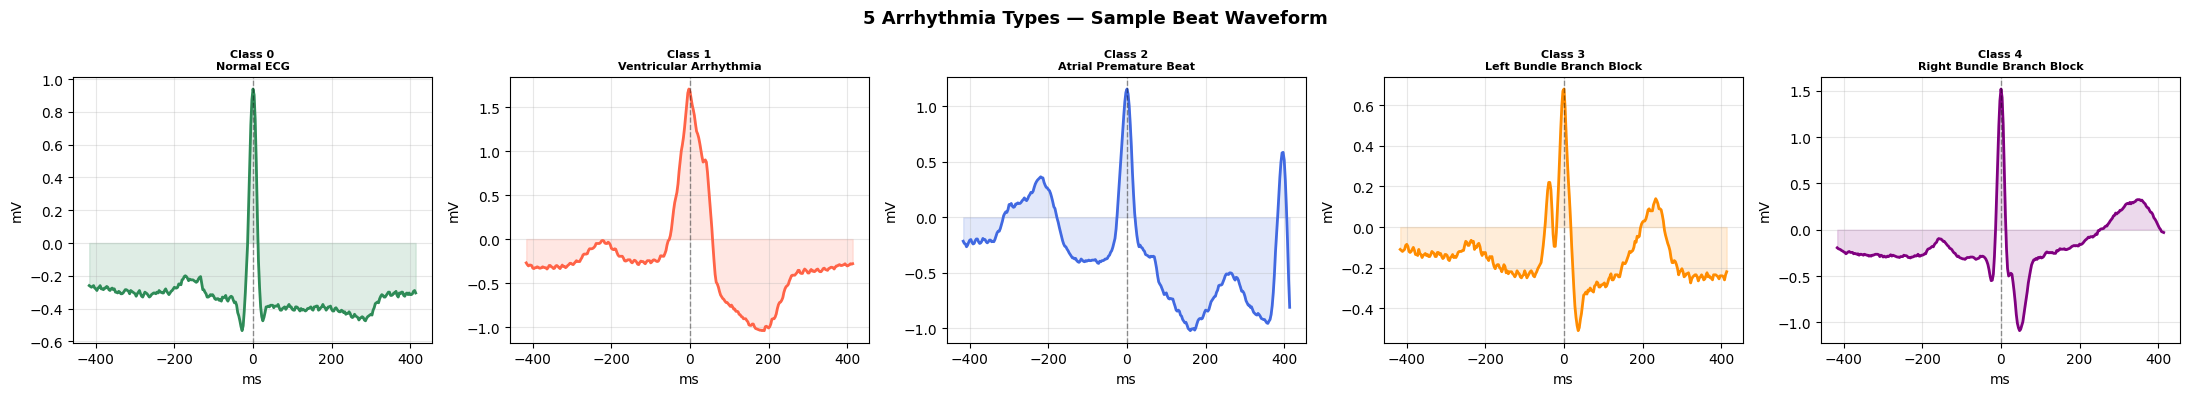

In [ ]:
# STEP 3 — Visualise 5 arrhythmia types
CLASS_SOURCE = {0:'100', 1:'208', 2:'202', 3:'111', 4:'231'}
CLASS_SYM    = {0:'N',   1:'V',   2:'A',   3:'L',   4:'R'}
examples     = {}

print('Loading sample beats for each arrhythmia type...')
for cls_id, rec in CLASS_SOURCE.items():
    try:
        rec_obj = wfdb.rdrecord(rec, pn_dir='mitdb')
        ann_obj = wfdb.rdann(rec, 'atr', pn_dir='mitdb')
        sig     = rec_obj.p_signal[:,0]
        _, inf  = nk.ecg_process(sig, sampling_rate=SAMPLING_RATE)
        rp      = inf['ECG_R_Peaks']
        a_s     = np.array(ann_obj.sample)
        a_y     = ann_obj.symbol
        for r in rp:
            if r-BEAT_WINDOW > 0 and r+BEAT_WINDOW < len(sig):
                diffs = np.abs(a_s - r)
                near  = np.argmin(diffs)
                if diffs[near] <= 2 and a_y[near] == CLASS_SYM[cls_id]:
                    examples[cls_id] = sig[r-BEAT_WINDOW:r+BEAT_WINDOW]
                    break
    except Exception as e:
        print(f'  Class {cls_id}: {e}')

for cls_id in range(5):
    print(f'  Class {cls_id} ({CLASS_NAMES[cls_id]}): {"Found" if cls_id in examples else "NOT FOUND"}')

beat_ms = np.arange(-BEAT_WINDOW, BEAT_WINDOW) / SAMPLING_RATE * 1000
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('5 Arrhythmia Types — Sample Beat Waveform', fontsize=13, fontweight='bold')
for cls_id in range(5):
    ax = axes[cls_id]
    if cls_id in examples:
        ax.plot(beat_ms, examples[cls_id], color=COLORS[cls_id], lw=2)
        ax.fill_between(beat_ms, examples[cls_id], alpha=0.15, color=COLORS[cls_id])
        ax.axvline(0, color='black', ls='--', alpha=0.4, lw=1)
    ax.set_title(f'Class {cls_id}\n{CLASS_NAMES[cls_id]}', fontweight='bold', fontsize=8)
    ax.set_xlabel('ms'); ax.set_ylabel('mV'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arrhythmia_types.png', dpi=150, bbox_inches='tight')
plt.show()

Loading ALL 48 MIT-BIH records...
Total sequences : 84,663  shape=(84663, 10, 300)
Class distribution: {np.int32(0): np.int64(66634), np.int32(1): np.int64(2929), np.int32(2): np.int64(1987), np.int32(3): np.int64(6270), np.int32(4): np.int64(6843)}


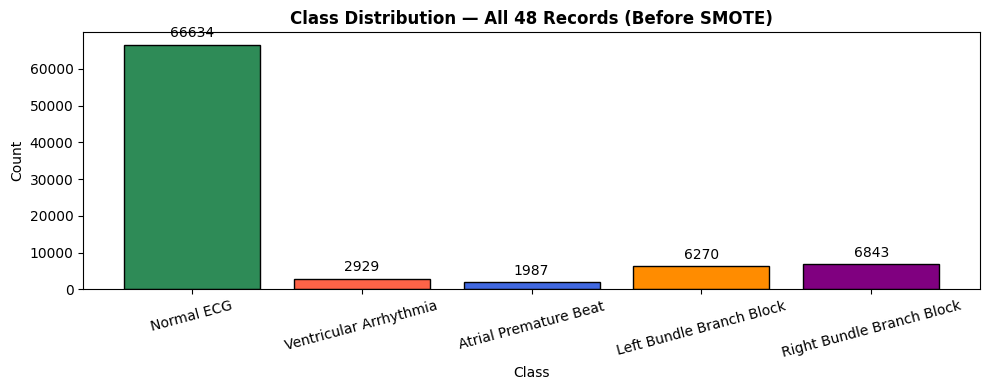

In [ ]:
# STEP 4 — Load ALL 48 records
all_seqs, all_labels = [], []
half = SEQ_LEN // 2

print(f'Loading ALL {len(ALL_RECORDS)} MIT-BIH records...')

for rec in ALL_RECORDS:
    try:
        record = wfdb.rdrecord(rec, pn_dir='mitdb')
        ann    = wfdb.rdann(rec, 'atr', pn_dir='mitdb')
        signal = record.p_signal[:,0]
        _, info = nk.ecg_process(signal, sampling_rate=SAMPLING_RATE)
        r_peaks = info['ECG_R_Peaks']
        ann_s = np.array(ann.sample)
        ann_y = ann.symbol

        for i in range(half, len(r_peaks)-half):
            seq, valid = [], True
            for j in range(i-half, i+half):
                r = r_peaks[j]
                if r-BEAT_WINDOW > 0 and r+BEAT_WINDOW < len(signal):
                    seq.append(signal[r-BEAT_WINDOW:r+BEAT_WINDOW])
                else:
                    valid = False; break
            if not valid or len(seq) != SEQ_LEN:
                continue
            diffs = np.abs(ann_s - r_peaks[i])
            near  = np.argmin(diffs)
            if diffs[near] <= 2 and ann_y[near] in LABEL_MAP:
                all_seqs.append(seq)
                all_labels.append(LABEL_MAP[ann_y[near]])
    except Exception as e:
        print(f'  Skipped {rec}: {e}')

X_all = np.array(all_seqs,   dtype=np.float32)
y_all = np.array(all_labels, dtype=np.int32)

print(f'Total sequences : {len(X_all):,}  shape={X_all.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y_all, return_counts=True)))}')

fig, ax = plt.subplots(figsize=(10,4))
cc = dict(zip(*np.unique(y_all, return_counts=True)))
bars = ax.bar([CLASS_NAMES[k] for k in sorted(cc)],
              [cc[k] for k in sorted(cc)],
              color=COLORS, edgecolor='black')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Class Distribution — All 48 Records (Before SMOTE)', fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Train: 67,730 | Test: 16,933
Train class: {np.int32(0): np.int64(53307), np.int32(1): np.int64(2343), np.int32(2): np.int64(1590), np.int32(3): np.int64(5016), np.int32(4): np.int64(5474)}
Test  class: {np.int32(0): np.int64(13327), np.int32(1): np.int64(586), np.int32(2): np.int64(397), np.int32(3): np.int64(1254), np.int32(4): np.int64(1369)}
Normalised
After SMOTE: 266,535
After limit: 40,000 (8000/class)
After shuffle — first 20: [4 2 3 0 3 4 1 3 2 3 2 1 0 1 4 0 2 2 3 4]
Class counts: {np.int32(0): np.int64(8000), np.int32(1): np.int64(8000), np.int32(2): np.int64(8000), np.int32(3): np.int64(8000), np.int32(4): np.int64(8000)}


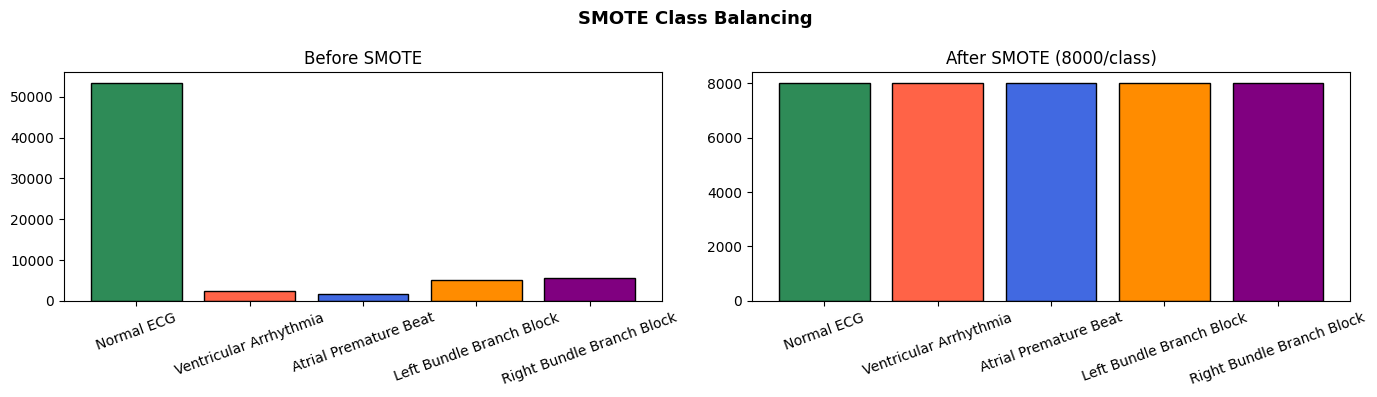

Class weights: {np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0), np.int32(2): np.float64(1.0), np.int32(3): np.float64(1.0), np.int32(4): np.float64(1.0)}
SVM  train: (40000, 3000)
CNN  train: (40000, 3000, 1)
LSTM train: (40000, 10, 300, 1)
RAM: 4.9/13.6 GB — safe to train


In [ ]:
# STEP 5 — Random 80/20 split + Normalise + SMOTE + Reshape
# ═══ CHANGE 2: Random split ═══

# Random 80/20 split
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)
print(f'Train: {len(X_train_raw):,} | Test: {len(X_test_raw):,}')
print(f'Train class: {dict(zip(*np.unique(y_train_raw, return_counts=True)))}')
print(f'Test  class: {dict(zip(*np.unique(y_test,      return_counts=True)))}')

# Normalise
scaler    = StandardScaler()
X_tr_flat = X_train_raw.reshape(-1, 300)
X_te_flat = X_test_raw.reshape(-1, 300)
X_tr_flat = scaler.fit_transform(X_tr_flat)
X_te_flat = scaler.transform(X_te_flat)
X_train_n = X_tr_flat.reshape(-1, SEQ_LEN, 300)
X_test_n  = X_te_flat.reshape(-1, SEQ_LEN, 300)
print(f'Normalised')

# ═══ CHANGE 3: 8000 per class ═══
X_flat_s = X_train_n.reshape(len(X_train_n), -1)
smote    = SMOTE(random_state=42)
X_b, y_b = smote.fit_resample(X_flat_s, y_train_raw)
print(f'After SMOTE: {len(X_b):,}')

rus      = RandomUnderSampler(
    sampling_strategy={0:8000,1:8000,2:8000,3:8000,4:8000},
    random_state=42)
X_b, y_b = rus.fit_resample(X_b, y_b)
X_train_b = X_b.reshape(-1, SEQ_LEN, 300)
print(f'After limit: {len(X_train_b):,} (8000/class)')

X_train_b, y_train_bal = shuffle(X_train_b, y_b, random_state=42)
print(f'After shuffle — first 20: {y_train_bal[:20]}')
print(f'Class counts: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}')

# SMOTE plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('SMOTE Class Balancing', fontsize=13, fontweight='bold')
cb = dict(zip(*np.unique(y_train_raw, return_counts=True)))
ca = dict(zip(*np.unique(y_train_bal, return_counts=True)))
axes[0].bar([CLASS_NAMES[k] for k in sorted(cb)],
            [cb[k] for k in sorted(cb)], color=COLORS, edgecolor='black')
axes[0].set_title('Before SMOTE'); axes[0].tick_params(axis='x', rotation=20)
axes[1].bar([CLASS_NAMES[k] for k in sorted(ca)],
            [ca[k] for k in sorted(ca)], color=COLORS, edgecolor='black')
axes[1].set_title('After SMOTE (8000/class)'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('smote_balancing.png', dpi=150, bbox_inches='tight')
plt.show()

# Class weights
cw  = compute_class_weight('balanced', classes=np.unique(y_train_bal), y=y_train_bal)
class_weight_dict = dict(zip(np.unique(y_train_bal), cw))
print(f'Class weights: {class_weight_dict}')

# Model inputs
X_svm_train  = X_train_b.reshape(-1, SEQ_LEN*300)
X_svm_test   = X_test_n.reshape(-1,  SEQ_LEN*300)
X_cnn_train  = X_train_b.reshape(-1, SEQ_LEN*300, 1)
X_cnn_test   = X_test_n.reshape(-1,  SEQ_LEN*300, 1)
X_lstm_train = X_train_b.reshape(-1, SEQ_LEN, 300, 1)
X_lstm_test  = X_test_n.reshape(-1,  SEQ_LEN, 300, 1)

print(f'SVM  train: {X_svm_train.shape}')
print(f'CNN  train: {X_cnn_train.shape}')
print(f'LSTM train: {X_lstm_train.shape}')

# Free RAM
for var in ['X_tr_flat','X_te_flat','X_flat_s','X_b','y_b',
            'X_train_raw','X_test_raw','X_train_n','X_test_n',
            'X_train_b','all_seqs']:
    try: exec(f'del {var}')
    except: pass
gc.collect()
ram = psutil.virtual_memory()
print(f'RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB — safe to train')

---
## Model 1 — SVM

Training SVM...
SVM training complete


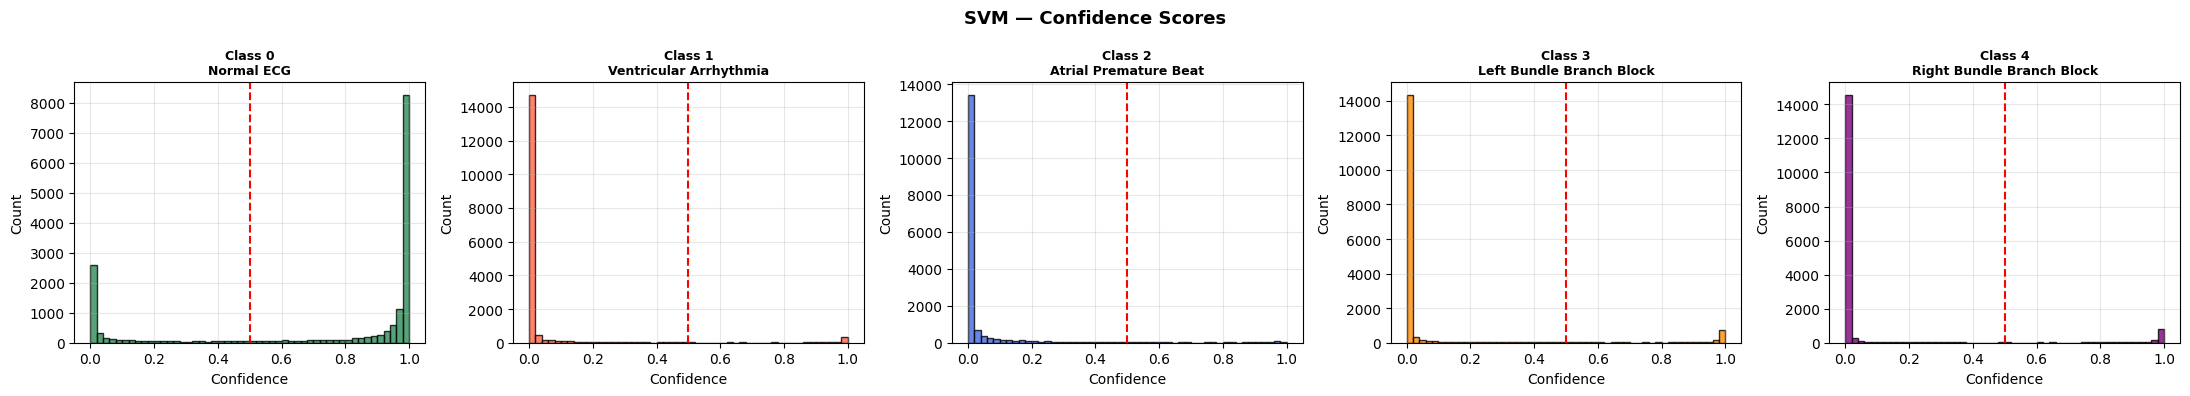

In [ ]:
# STEP 6 — Train SVM
print('Training SVM...')
base_svm  = LinearSVC(C=1.0, max_iter=5000, random_state=42)
svm_model = CalibratedClassifierCV(base_svm, cv=3)
svm_model.fit(X_svm_train, y_train_bal)
print('SVM training complete')

svm_scores = svm_model.predict_proba(X_svm_test)
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('SVM — Confidence Scores', fontsize=13, fontweight='bold')
for i in range(5):
    axes[i].hist(svm_scores[:,i], bins=50, color=COLORS[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Class {i}\n{CLASS_NAMES[i]}', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Confidence'); axes[i].set_ylabel('Count')
    axes[i].axvline(0.5, color='red', ls='--', lw=1.5)
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_confidence_scores.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Model 2 — CNN

In [ ]:
# STEP 7 — Train CNN
cnn_model = Sequential([
    Conv1D(32,  kernel_size=5, activation='relu', padding='same',
           input_shape=(SEQ_LEN*300, 1)),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.2),
    Conv1D(64,  kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.2),
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.2),
    Conv1D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'), BatchNormalization(), Dropout(0.4),
    Dense(64,  activation='relu'), Dropout(0.3),
    Dense(5,   activation='softmax')
], name='CNN')

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

cnn_history = cnn_model.fit(
    X_cnn_train, y_train_bal,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                          patience=3, mode='max', verbose=1)
    ],
    verbose=2
)
print(f'CNN done — best val_acc: {max(cnn_history.history["val_accuracy"])*100:.2f}%')

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3000, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1500, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1500, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 750, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 750, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 750, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 750, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 375, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 375, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 375, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 375, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 187, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 187, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 47872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,127,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,272,517 (23.93 MB)

 Trainable params: 6,271,301 (23.92 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/20
1000/1000 - 41s - 41ms/step - accuracy: 0.9290 - loss: 0.2195 - val_accuracy: 0.9834 - val_loss: 0.0453 - learning_rate: 0.0010
Epoch 2/20
1000/1000 - 26s - 26ms/step - accuracy: 0.9742 - loss: 0.0799 - val_accuracy: 0.9805 - val_loss: 0.0600 - learning_rate: 0.0010
Epoch 3/20
1000/1000 - 26s - 26ms/step - accuracy: 0.9820 - loss: 0.0552 - val_accuracy: 0.9915 - val_loss: 0.0327 - learning_rate: 0.0010
Epoch 4/20
1000/1000 - 27s - 27ms/step - accuracy: 0.9892 - loss: 0.0332 - val_accuracy: 0.9954 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 5/20
1000/1000 - 27s - 27ms/step - accuracy: 0.9898 - loss: 0.0324 - val_accuracy: 0.9934 - val_loss: 0.0217 - learning_rate: 0.0010
Epoch 6/20
1000/1000 - 27s - 27ms/step - accuracy: 0.9921 - loss: 0.0238 - val_accuracy: 0.9946 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 7/20

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1000/1000 - 27s - 27ms/step - accuracy: 0.9931 - loss: 0.0224 - val_accuracy: 

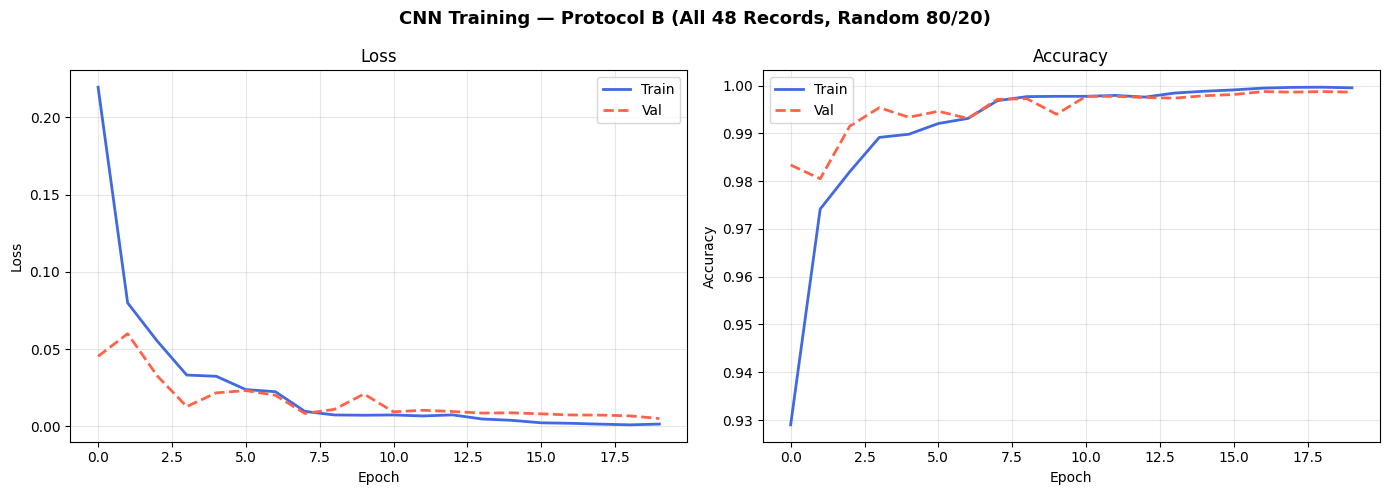

In [ ]:
# STEP 8 — CNN training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training — Protocol B (All 48 Records, Random 80/20)',
             fontsize=13, fontweight='bold')
axes[0].plot(cnn_history.history['loss'],         color='royalblue', label='Train', lw=2)
axes[0].plot(cnn_history.history['val_loss'],     color='tomato',    label='Val',   lw=2, ls='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(cnn_history.history['accuracy'],     color='royalblue', label='Train', lw=2)
axes[1].plot(cnn_history.history['val_accuracy'], color='tomato',    label='Val',   lw=2, ls='--')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Model 3 — CNN-BiLSTM

In [ ]:
# STEP 9 — Train CNN-BiLSTM
inp = Input(shape=(SEQ_LEN, 300, 1))
x = TimeDistributed(Conv1D(32, 5, activation='relu', padding='same'))(inp)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling1D(2))(x)
x = TimeDistributed(Dropout(0.2))(x)
x = TimeDistributed(Conv1D(64, 5, activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling1D(2))(x)
x = TimeDistributed(Dropout(0.2))(x)
x = TimeDistributed(Conv1D(128, 3, activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling1D(2))(x)
x = TimeDistributed(Dropout(0.2))(x)
x = TimeDistributed(Flatten())(x)
x = Bidirectional(LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
x = Bidirectional(LSTM(128, return_sequences=False, dropout=0.2, recurrent_dropout=0.1))(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(5, activation='softmax')(x)

cnn_lstm_model = Model(inp, out, name='CNN_BiLSTM')
cnn_lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_lstm_model.summary()

cnn_lstm_history = cnn_lstm_model.fit(
    X_lstm_train, y_train_bal,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                          patience=3, mode='max', verbose=1)
    ],
    verbose=2
)
print(f'CNN-BiLSTM done — best val_acc: {max(cnn_lstm_history.history["val_accuracy"])*100:.2f}%')

Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 300, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 300, 32)    │           192 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 300, 32)    │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 150, 32)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 150, 32)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 150, 64)    │        10,304 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 150, 64)    │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 75, 64)     │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 75, 64)     │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 10, 75, 128)    │        24,704 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 10, 75, 128)    │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 10, 37, 128)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 10, 37, 128)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 10, 4736)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 512)        │    10,225,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 10,960,133 (41.81 MB)

 Trainable params: 10,959,429 (41.81 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/20
1000/1000 - 165s - 165ms/step - accuracy: 0.8620 - loss: 0.3995 - val_accuracy: 0.9160 - val_loss: 0.2492 - learning_rate: 0.0010
Epoch 2/20
1000/1000 - 140s - 140ms/step - accuracy: 0.9147 - loss: 0.2460 - val_accuracy: 0.9221 - val_loss: 0.2209 - learning_rate: 0.0010
Epoch 3/20
1000/1000 - 141s - 141ms/step - accuracy: 0.9230 - loss: 0.2171 - val_accuracy: 0.9249 - val_loss: 0.2134 - learning_rate: 0.0010
Epoch 4/20
1000/1000 - 139s - 139ms/step - accuracy: 0.9356 - loss: 0.1865 - val_accuracy: 0.9434 - val_loss: 0.1747 - learning_rate: 0.0010
Epoch 5/20
1000/1000 - 141s - 141ms/step - accuracy: 0.9408 - loss: 0.1761 - val_accuracy: 0.9469 - val_loss: 0.1602 - learning_rate: 0.0010
Epoch 6/20
1000/1000 - 138s - 138ms/step - accuracy: 0.9511 - loss: 0.1466 - val_accuracy: 0.9586 - val_loss: 0.1247 - learning_rate: 0.0010
Epoch 7/20
1000/1000 - 139s - 139ms/step - accuracy: 0.9653 - loss: 0.1115 - val_accuracy: 0.9709 - val_loss: 0.0981 - learning_rate: 0.0010
Epoch 8/20
10

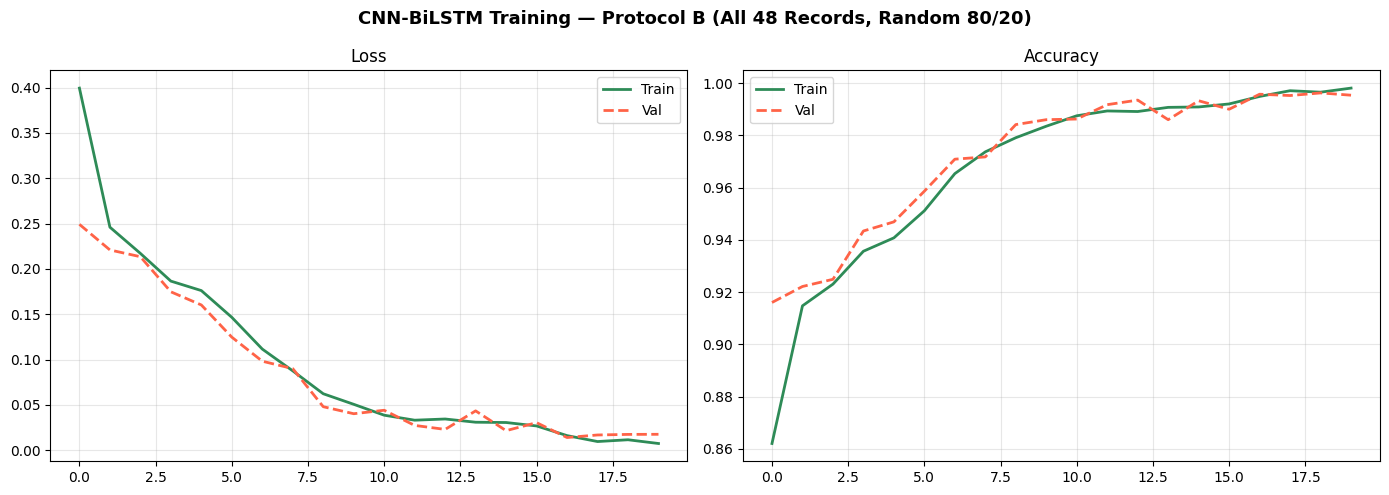

In [ ]:
# STEP 10 — CNN-BiLSTM training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN-BiLSTM Training — Protocol B (All 48 Records, Random 80/20)',
             fontsize=13, fontweight='bold')
axes[0].plot(cnn_lstm_history.history['loss'],         color='seagreen', label='Train', lw=2)
axes[0].plot(cnn_lstm_history.history['val_loss'],     color='tomato',   label='Val',   lw=2, ls='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(cnn_lstm_history.history['accuracy'],     color='seagreen', label='Train', lw=2)
axes[1].plot(cnn_lstm_history.history['val_accuracy'], color='tomato',   label='Val',   lw=2, ls='--')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Evaluation

In [ ]:
# STEP 11 — Predictions
svm_pred       = svm_model.predict(X_svm_test)
svm_proba      = svm_model.predict_proba(X_svm_test)
cnn_proba      = cnn_model.predict(X_cnn_test, verbose=0)
cnn_pred       = cnn_proba.argmax(axis=1)
cnn_lstm_proba = cnn_lstm_model.predict(X_lstm_test, verbose=0)
cnn_lstm_pred  = cnn_lstm_proba.argmax(axis=1)
print(f'Predictions done — Test set: {len(y_test):,} sequences')

Predictions done — Test set: 16,933 sequences


In [ ]:
# STEP 12 — Metrics
def compute_metrics(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true,   y_pred,  average='weighted', zero_division=0)
    f1   = f1_score(y_true,       y_pred,  average='weighted', zero_division=0)
    print(f'\n{"="*55}\n  {name}\n{"="*55}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred,
          target_names=list(CLASS_NAMES.values()), zero_division=0))
    return {'Model':name,'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1}

m_svm  = compute_metrics(y_test, svm_pred,      'SVM   — Protocol B (Random 80/20)')
m_cnn  = compute_metrics(y_test, cnn_pred,       'CNN   — Protocol B (Random 80/20)')
m_lstm = compute_metrics(y_test, cnn_lstm_pred,  'CNN-BiLSTM — Protocol B (Random 80/20)')


  SVM   — Protocol B (Random 80/20)
  Accuracy  : 94.68%
  Precision : 0.9580
  Recall    : 0.9468
  F1-Score  : 0.9502

                           precision    recall  f1-score   support

               Normal ECG       0.99      0.94      0.97     13327
   Ventricular Arrhythmia       0.73      0.93      0.82       586
    Atrial Premature Beat       0.52      0.86      0.65       397
 Left Bundle Branch Block       0.88      0.97      0.93      1254
Right Bundle Branch Block       0.92      0.97      0.95      1369

                 accuracy                           0.95     16933
                macro avg       0.81      0.94      0.86     16933
             weighted avg       0.96      0.95      0.95     16933


  CNN   — Protocol B (Random 80/20)
  Accuracy  : 99.25%
  Precision : 0.9931
  Recall    : 0.9925
  F1-Score  : 0.9927

                           precision    recall  f1-score   support

               Normal ECG       1.00      0.99      1.00     13327
   Ventricular 

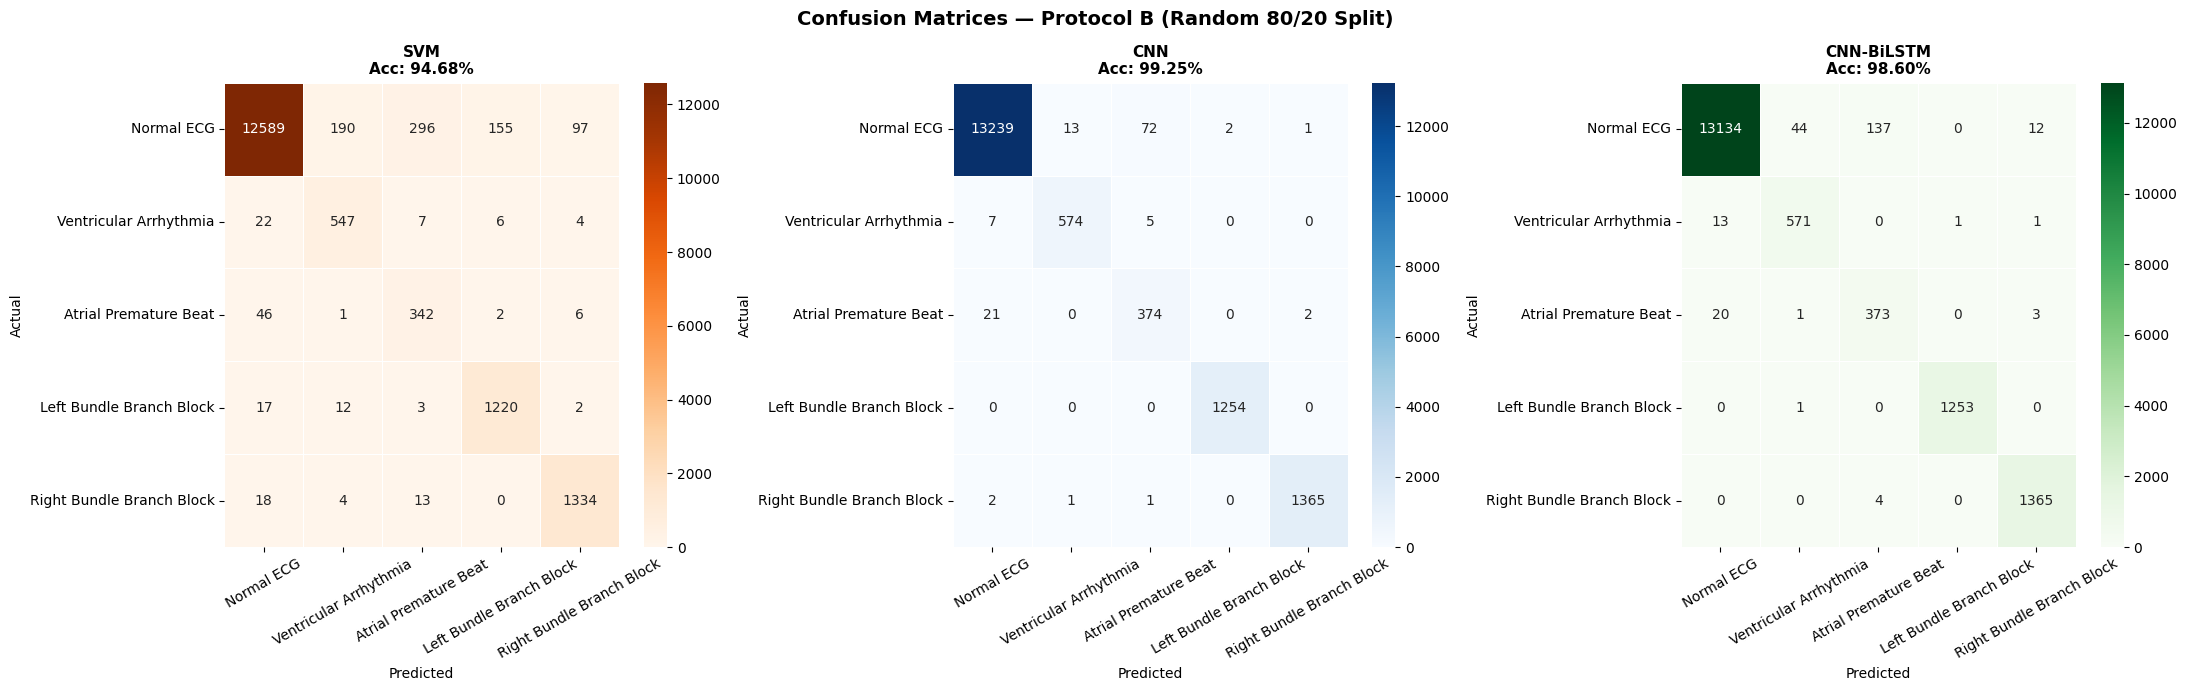

In [ ]:
# STEP 13 — Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Confusion Matrices — Protocol B (Random 80/20 Split)',
             fontsize=14, fontweight='bold')
class_labels = list(CLASS_NAMES.values())
for ax, pred, name, cmap in zip(
    axes,
    [svm_pred, cnn_pred, cnn_lstm_pred],
    ['SVM','CNN','CNN-BiLSTM'],
    ['Oranges','Blues','Greens']
):
    cm  = confusion_matrix(y_test, pred)
    acc = accuracy_score(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=class_labels, yticklabels=class_labels, linewidths=0.5)
    ax.set_title(f'{name}\nAcc: {acc*100:.2f}%', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

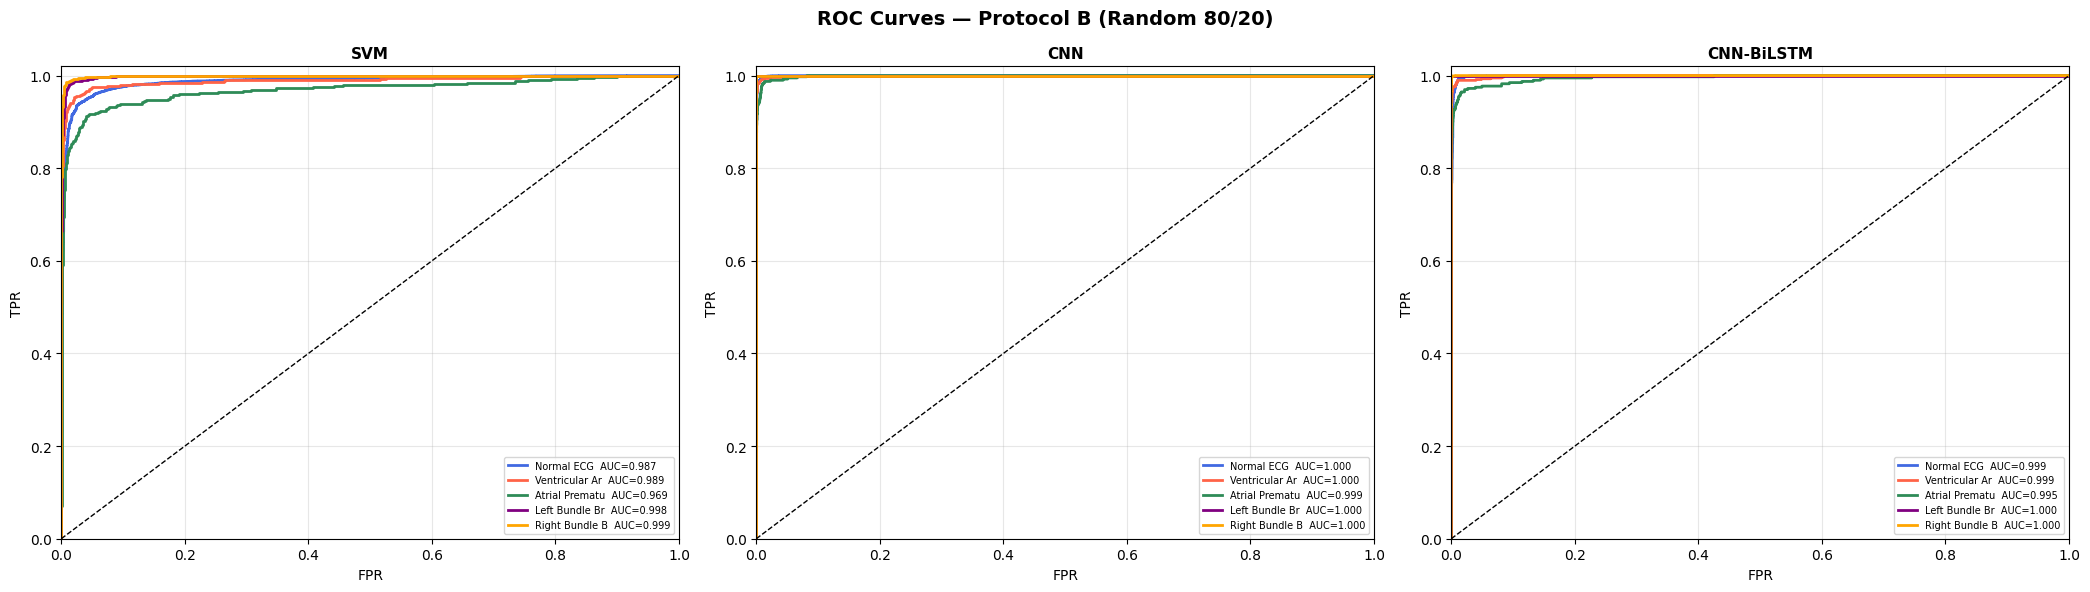

In [ ]:
# STEP 14 — ROC curves
colors_roc = ['royalblue','tomato','seagreen','purple','orange']
def plot_roc(ax, proba, title):
    y_bin = label_binarize(y_test, classes=list(range(5)))
    for i in range(5):
        fpr, tpr, _ = roc_curve(y_bin[:,i], proba[:,i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
                label=f'{CLASS_NAMES[i][:14]}  AUC={roc_auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('ROC Curves — Protocol B (Random 80/20)', fontsize=14, fontweight='bold')
plot_roc(axes[0], svm_proba,       'SVM')
plot_roc(axes[1], cnn_proba,       'CNN')
plot_roc(axes[2], cnn_lstm_proba,  'CNN-BiLSTM')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


  FINAL RESULTS — PROTOCOL A (Random 80/20 Split)
                                        Accuracy  Precision  Recall     F1
Model                                                                     
SVM   — Protocol B (Random 80/20)         0.9468     0.9580  0.9468 0.9502
CNN   — Protocol B (Random 80/20)         0.9925     0.9931  0.9925 0.9927
CNN-BiLSTM — Protocol B (Random 80/20)    0.9860     0.9880  0.9860 0.9866


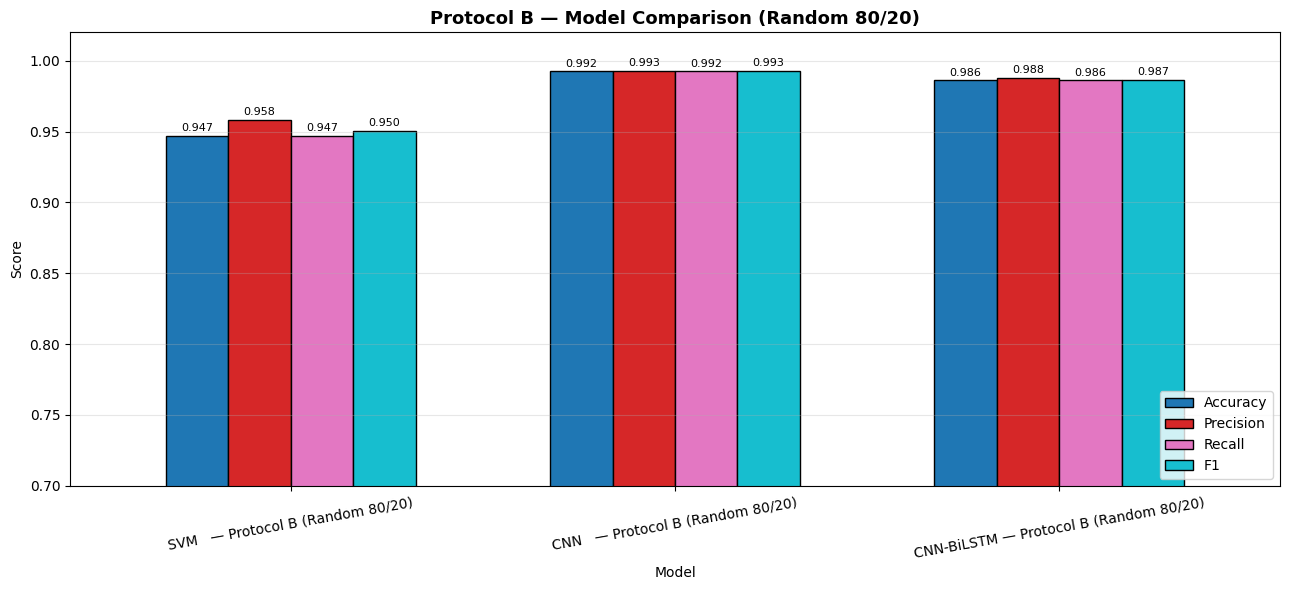

In [ ]:
# STEP 15 — Model comparison bar chart
summary_df = pd.DataFrame([m_svm, m_cnn, m_lstm]).set_index('Model')
print('\n' + '='*65)
print('  FINAL RESULTS — PROTOCOL A (Random 80/20 Split)')
print('='*65)
print(summary_df.to_string(float_format='{:.4f}'.format))
print('='*65)

ax = summary_df.plot(kind='bar', figsize=(13,6),
                     colormap='tab10', edgecolor='black', width=0.65)
ax.set_title('Protocol B — Model Comparison (Random 80/20)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim([0.70, 1.02])
ax.set_xticklabels(summary_df.index, rotation=10, fontsize=10)
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3, axis='y')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

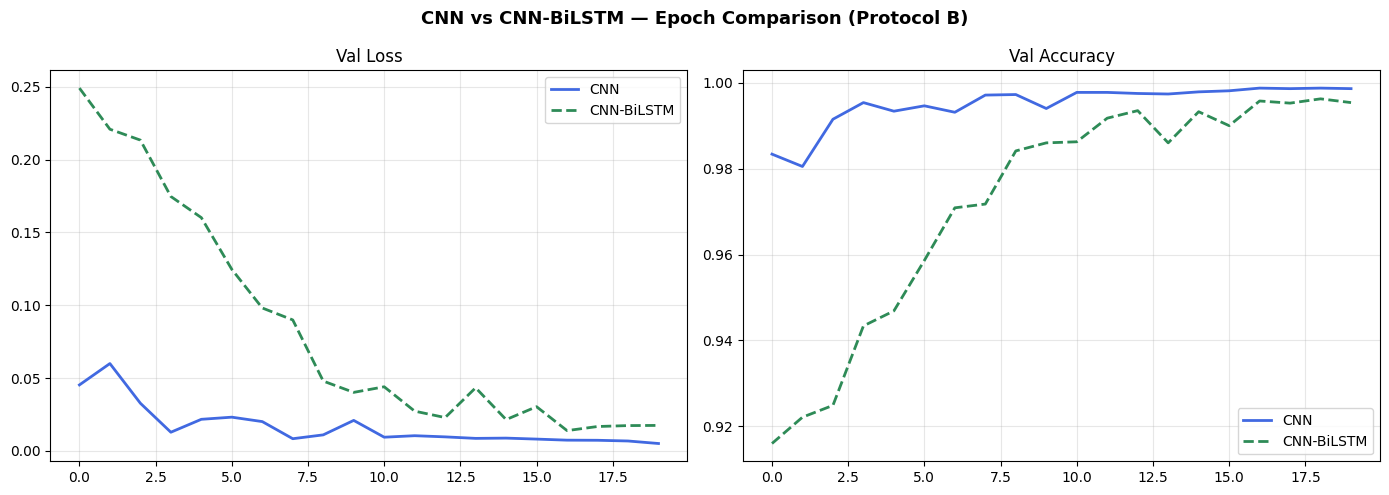

In [ ]:
# STEP 16 — Epoch comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN vs CNN-BiLSTM — Epoch Comparison (Protocol B)',
             fontsize=13, fontweight='bold')
axes[0].plot(cnn_history.history['val_loss'],         color='royalblue', label='CNN',       lw=2)
axes[0].plot(cnn_lstm_history.history['val_loss'],    color='seagreen',  label='CNN-BiLSTM',lw=2, ls='--')
axes[0].set_title('Val Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(cnn_history.history['val_accuracy'],     color='royalblue', label='CNN',       lw=2)
axes[1].plot(cnn_lstm_history.history['val_accuracy'],color='seagreen',  label='CNN-BiLSTM',lw=2, ls='--')
axes[1].set_title('Val Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('epoch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Single Patient Medical Report

In [ ]:
# STEP 17 — Load patient record
print(f'Loading patient record: {TEST_RECORD}...')
record_test = wfdb.rdrecord(TEST_RECORD, pn_dir='mitdb')
ann_test    = wfdb.rdann(TEST_RECORD, 'atr', pn_dir='mitdb')
full_signal = record_test.p_signal[:, 0]
signals_df, info_test = nk.ecg_process(full_signal, sampling_rate=SAMPLING_RATE)

def safe_peaks(info, key):
    raw = info.get(key, [])
    arr = np.asarray(raw, dtype=float)
    return arr[~np.isnan(arr)].astype(int)

r_idx = safe_peaks(info_test, 'ECG_R_Peaks')
p_idx = safe_peaks(info_test, 'ECG_P_Peaks')
q_idx = safe_peaks(info_test, 'ECG_Q_Peaks')
s_idx = safe_peaks(info_test, 'ECG_S_Peaks')
t_idx = safe_peaks(info_test, 'ECG_T_Peaks')
p_on  = safe_peaks(info_test, 'ECG_P_Onsets')
t_off = safe_peaks(info_test, 'ECG_T_Offsets')
print(f'Record {TEST_RECORD}: {len(full_signal):,} samples | {len(r_idx)} R-peaks')

Loading patient record: 231...
Record 231: 650,000 samples | 2015 R-peaks


In [ ]:
# STEP 18 — Compute ECG intervals
def to_ms(s):  return int(round(s / SAMPLING_RATE * 1000))
def to_sec(s): return round(s / SAMPLING_RATE, 2)

hr     = int(signals_df['ECG_Rate'].mean())
rr_arr = np.diff(r_idx)
rr_ms  = to_ms(int(np.median(rr_arr)))
rr_sec = to_sec(int(np.median(rr_arr)))
rr_cv  = rr_arr.std() / rr_arr.mean() if len(rr_arr) > 1 else 0

pr_list, qrs_list, qt_list = [], [], []
for r in r_idx:
    pb = p_on[p_on < r]
    if len(pb):
        d = to_ms(r - pb[-1])
        if 80 <= d <= 300: pr_list.append(d)
    qb = q_idx[q_idx < r]; sa = s_idx[s_idx > r]
    if len(qb) and len(sa):
        d = to_ms(sa[0] - qb[-1])
        if 40 <= d <= 200: qrs_list.append(d)
    ta = t_off[t_off > r]
    if len(qb) and len(ta):
        d = to_ms(ta[0] - qb[-1])
        if 200 <= d <= 700: qt_list.append(d)

pr_ms  = int(np.median(pr_list))  if pr_list  else 160
qrs_ms = int(np.median(qrs_list)) if qrs_list else 90
qt_ms  = int(np.median(qt_list))  if qt_list  else 400
qtc_ms = int(round(qt_ms / np.sqrt(max(rr_sec, 0.3))))
baseline = float(np.median(full_signal))
rv5_mv   = round(float(np.max(full_signal[r_idx])) - baseline, 2)   if len(r_idx)>0 else 0.0
sv1_mv   = round(abs(float(np.min(full_signal[s_idx]))-baseline), 2) if len(s_idx)>0 else 0.0
lvh_sum  = round(rv5_mv+sv1_mv, 2)
p_amp    = round(float(np.mean(full_signal[p_idx]))-baseline, 3) if len(p_idx)>0 else 0.0
r_amp    = round(float(np.mean(full_signal[r_idx]))-baseline, 3) if len(r_idx)>0 else 0.0
st_off   = int(0.08*SAMPLING_RATE)
st_vals  = [full_signal[r+st_off]-baseline for r in r_idx if r+st_off<len(full_signal)]
st_level = round(float(np.mean(st_vals)), 3) if st_vals else 0.0

if   hr<60:  rhythm = f'Bradycardia — Abnormal ({hr} bpm < 60)'
elif hr>100: rhythm = f'Tachycardia — Abnormal ({hr} bpm > 100)'
else:        rhythm = f'Normal Sinus Rhythm ({hr} bpm)'
rr_status  = 'Irregular — possible AF' if rr_cv>0.10 else 'Regular'
pr_status  = (f'{pr_ms}ms — SHORT  (WPW possible)' if pr_ms<120 else
              f'{pr_ms}ms — LONG   (1st AV block)'  if pr_ms>200 else
              f'{pr_ms}ms — Normal (120-200ms)')
qrs_status = (f'{qrs_ms}ms — WIDE   (BBB)' if qrs_ms>120 else
              f'{qrs_ms}ms — Normal (60-120ms)')
qt_status  = (f'{qt_ms}ms — LONG   (Torsades risk)' if qt_ms>440 else
              f'{qt_ms}ms — Normal (350-440ms)')
qtc_status = f'{qtc_ms}ms — PROLONGED' if qtc_ms>440 else f'{qtc_ms}ms — Normal'
st_status  = (f'{st_level}mV — ELEVATED'  if st_level> 0.1 else
              f'{st_level}mV — DEPRESSED'  if st_level<-0.1 else
              f'{st_level}mV — Isoelectric (Normal)')
lvh_note   = f'{lvh_sum}mV — Possible LVH (>3.5mV)' if lvh_sum>3.5 else f'{lvh_sum}mV — Normal'

print(f'HR={hr}bpm | PR={pr_ms}ms | QRS={qrs_ms}ms | QT={qt_ms}ms | QTc={qtc_ms}ms')

HR=67bpm | PR=203ms | QRS=78ms | QT=467ms | QTc=482ms


In [ ]:
# STEP 19 — Classify + Medical Report
TARGET_BEAT = 25
h = SEQ_LEN // 2
sequence, valid = [], True
for j in range(TARGET_BEAT-h, TARGET_BEAT+h):
    if j<0 or j>=len(r_idx): valid=False; break
    r = r_idx[j]
    if r-BEAT_WINDOW>0 and r+BEAT_WINDOW<len(full_signal):
        sequence.append(full_signal[r-BEAT_WINDOW:r+BEAT_WINDOW])
    else: valid=False; break
if not valid or len(sequence)!=SEQ_LEN:
    sequence=[full_signal[r_idx[j]-BEAT_WINDOW:r_idx[j]+BEAT_WINDOW] for j in range(20,30)]

seq_norm = scaler.transform(np.array(sequence).reshape(-1,300))
seq_3d   = seq_norm.reshape(1,SEQ_LEN,300)
svm_cls  = int(svm_model.predict(seq_3d.reshape(1,-1))[0])
cnn_cls  = int(cnn_model.predict(seq_3d.reshape(1,SEQ_LEN*300,1), verbose=0).argmax())
lstm_cls = int(cnn_lstm_model.predict(seq_3d.reshape(1,SEQ_LEN,300,1), verbose=0).argmax())
votes    = Counter([svm_cls,cnn_cls,lstm_cls])
final_cls= votes.most_common(1)[0][0]
vote_count=votes.most_common(1)[0][1]
diagnosis= CLASS_NAMES[final_cls]
beat_raw = sequence[SEQ_LEN//2]

print()
print('='*65)
print(f'        ECG ANALYSIS REPORT — Record {TEST_RECORD}')
print(f'        Protocol B — All 48 Records / Random 80/20')
print(f'        IIT Jodhpur — M.Tech AI Project | M25AI1054')
print('='*65)
print(f'  Heart Rate  : {hr} bpm  [{rhythm}]')
print(f'  R-R Interval: {rr_sec}s ({rr_ms}ms) [{rr_status}]')
print(f'  PR Interval : {pr_status}')
print(f'  QRS Duration: {qrs_status}')
print(f'  QT Interval : {qt_status}')
print(f'  QTc (Bazett): {qtc_status}')
print(f'  P-wave amp  : {p_amp} mV')
print(f'  R-wave amp  : {r_amp} mV')
print(f'  RV5+SV1     : {lvh_note}')
print(f'  ST Segment  : {st_status}')
print()
print(f'  SVM        : {CLASS_NAMES[svm_cls]}')
print(f'  CNN        : {CLASS_NAMES[cnn_cls]}')
print(f'  CNN-BiLSTM : {CLASS_NAMES[lstm_cls]}')
print(f'  MAJORITY ({vote_count}/3) → FINAL: {diagnosis}')
print('='*65)


        ECG ANALYSIS REPORT — Record 231
        Protocol B — All 48 Records / Random 80/20
        IIT Jodhpur — M.Tech AI Project | M25AI1054
  Heart Rate  : 67 bpm  [Normal Sinus Rhythm (67 bpm)]
  R-R Interval: 0.94s (944ms) [Irregular — possible AF]
  PR Interval : 203ms — LONG   (1st AV block)
  QRS Duration: 78ms — Normal (60-120ms)
  QT Interval : 467ms — LONG   (Torsades risk)
  QTc (Bazett): 482ms — PROLONGED
  P-wave amp  : 0.177 mV
  R-wave amp  : 1.084 mV
  RV5+SV1     : 3.4mV — Normal
  ST Segment  : -0.125mV — DEPRESSED

  SVM        : Right Bundle Branch Block
  CNN        : Right Bundle Branch Block
  CNN-BiLSTM : Right Bundle Branch Block
  MAJORITY (3/3) → FINAL: Right Bundle Branch Block


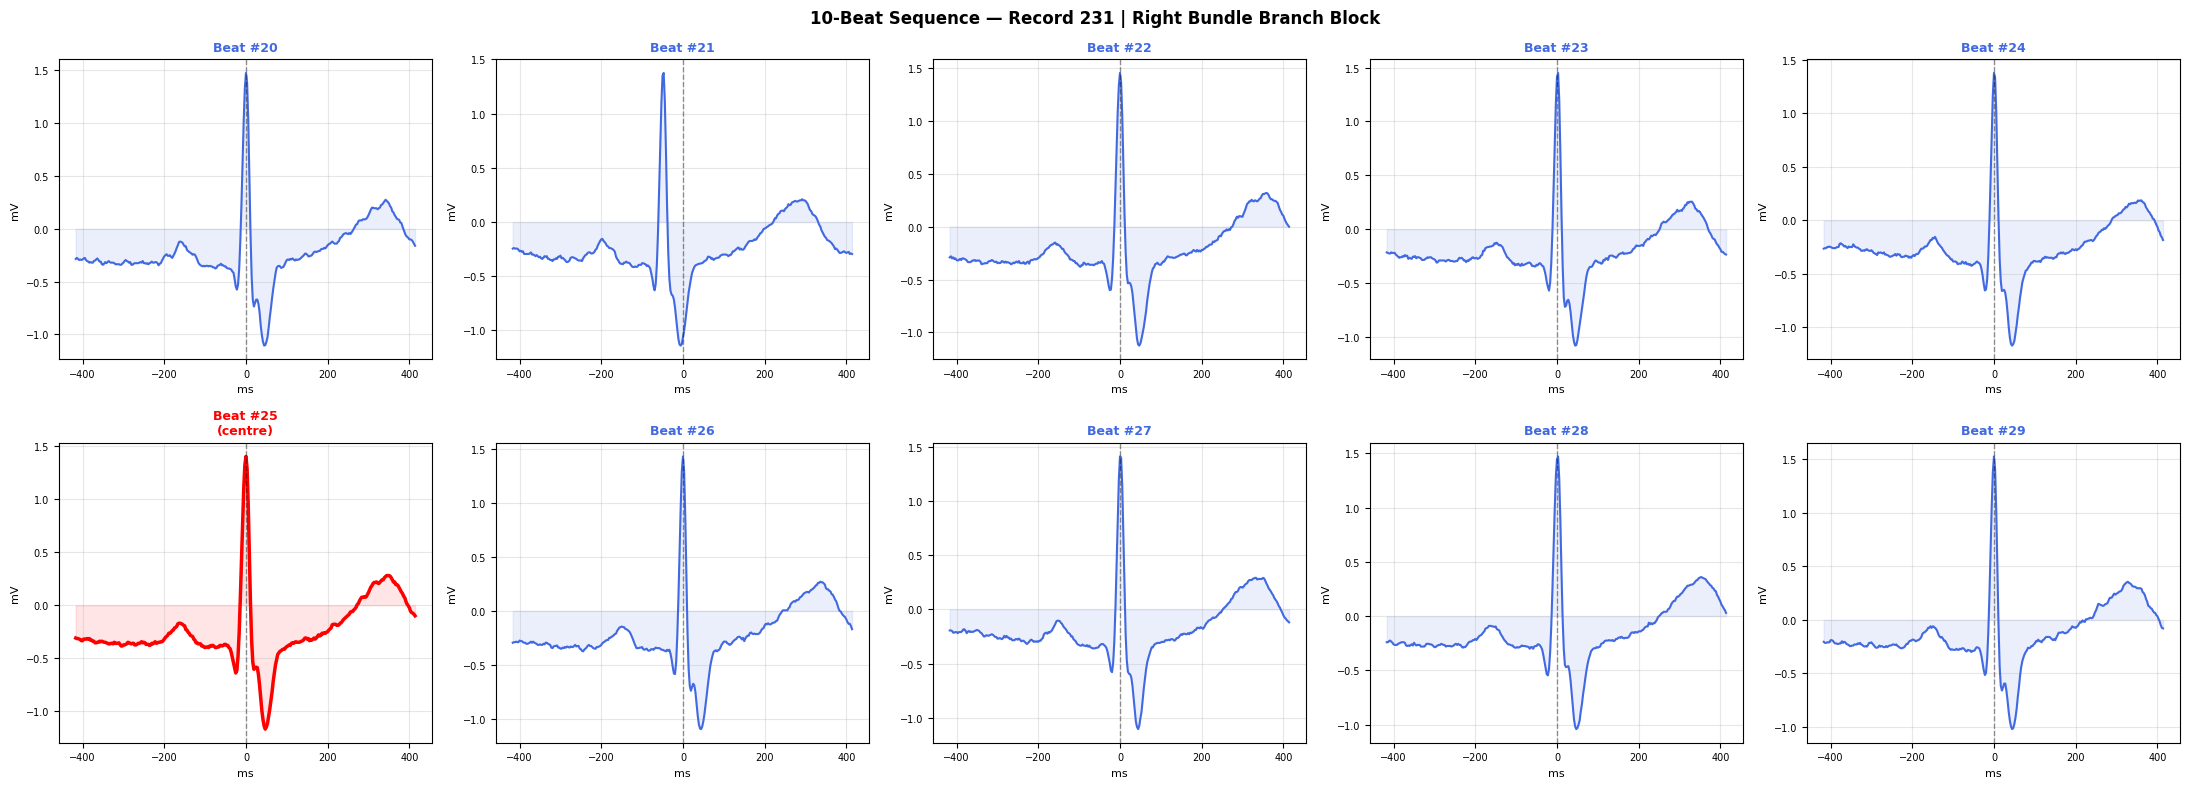

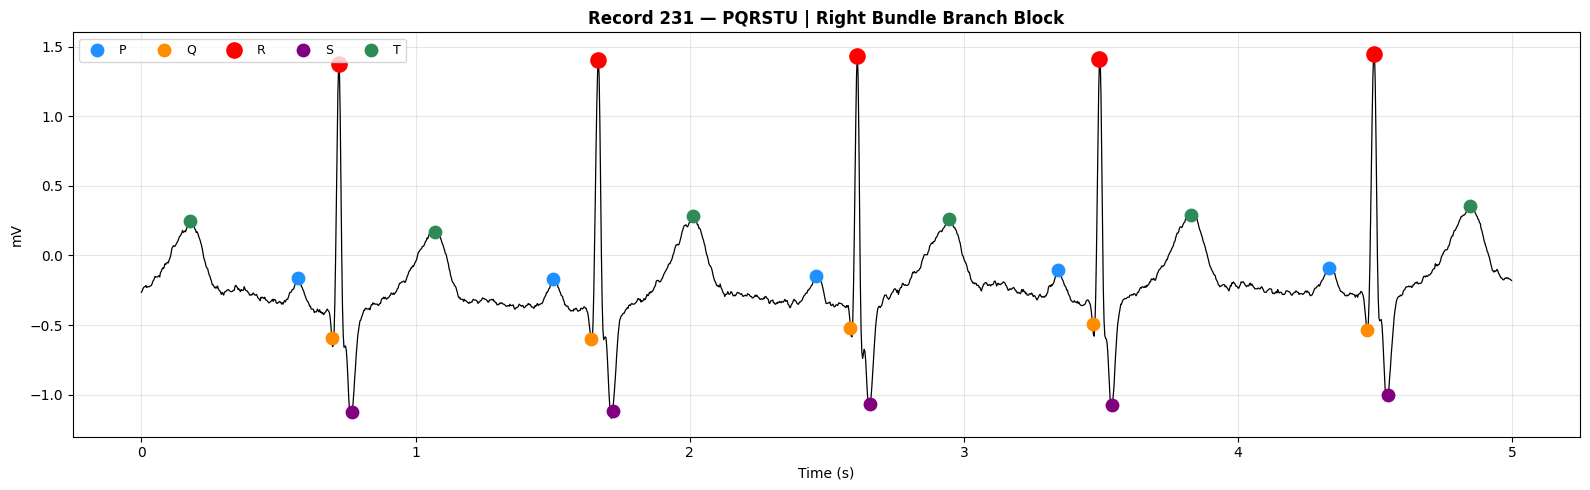

In [ ]:
# STEP 20 — Waveform + PQRSTU plots
beat_ms2 = np.arange(-BEAT_WINDOW, BEAT_WINDOW) / SAMPLING_RATE * 1000
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle(f'10-Beat Sequence — Record {TEST_RECORD} | {diagnosis}',
             fontsize=12, fontweight='bold')
for idx in range(SEQ_LEN):
    ax    = axes[idx//5][idx%5]
    is_c  = (idx==SEQ_LEN//2)
    color = 'red' if is_c else 'royalblue'
    ax.plot(beat_ms2, sequence[idx], color=color, lw=2.5 if is_c else 1.5)
    ax.fill_between(beat_ms2, sequence[idx], alpha=0.1, color=color)
    ax.axvline(0, color='black', ls='--', alpha=0.4, lw=1)
    bn = TARGET_BEAT-SEQ_LEN//2+idx
    ax.set_title(f'Beat #{bn}'+('\n(centre)' if is_c else ''),
                 fontsize=9, fontweight='bold', color=color)
    ax.set_xlabel('ms',fontsize=8); ax.set_ylabel('mV',fontsize=8)
    ax.grid(True,alpha=0.3); ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(f'10beat_sequence_{TEST_RECORD}.png', dpi=150, bbox_inches='tight')
plt.show()

TARGET_R = r_idx[TARGET_BEAT]
seg_s = max(0, TARGET_R-600); seg_e = min(len(full_signal), seg_s+1800)
seg   = full_signal[seg_s:seg_e]; t_ax = np.arange(len(seg))/SAMPLING_RATE
def in_seg(arr,s,e): return arr[(arr>=s)&(arr<e)]-s
fig, ax = plt.subplots(figsize=(16,5))
ax.plot(t_ax, seg, color='black', lw=0.9)
for arr,color,lbl,sz in [(in_seg(p_idx,seg_s,seg_e),'dodgerblue','P',80),
    (in_seg(q_idx,seg_s,seg_e),'darkorange','Q',80),
    (in_seg(r_idx,seg_s,seg_e),'red','R',120),
    (in_seg(s_idx,seg_s,seg_e),'purple','S',80),
    (in_seg(t_idx,seg_s,seg_e),'seagreen','T',80)]:
    if len(arr)>0:
        ax.scatter(arr/SAMPLING_RATE, seg[arr], c=color, s=sz, zorder=5, label=lbl)
ax.set_title(f'Record {TEST_RECORD} — PQRSTU | {diagnosis}', fontsize=12, fontweight='bold')
ax.set_xlabel('Time (s)'); ax.set_ylabel('mV')
ax.legend(ncol=5, fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'ecg_{TEST_RECORD}_pqrstu.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# STEP 21 — Final summary
print()
print('='*68)
print('  PROTOCOL B FINAL SUMMARY — All 48 Records / Random 80/20')
print('  ECG Signal Analysis | IIT Jodhpur | M25AI1054')
print('='*68)
print(f'  {"Model":<30} {"Acc%":>6} {"Prec":>7} {"Rec":>7} {"F1":>7}')
print('-'*68)
for m in [m_svm, m_cnn, m_lstm]:
    print(f'  {m["Model"]:<30} {m["Accuracy"]*100:>5.2f}%'
          f' {m["Precision"]:>7.4f} {m["Recall"]:>7.4f} {m["F1"]:>7.4f}')
print('='*68)
print()
print('COMPARE WITH PROTOCOL A NOTEBOOK:')
print('  Protocol A (patient-independent):')
print('    SVM      : 74.74%')
print('    CNN      : 79.63%')
print('    CNN-BiLSTM: 78.71%')
print()
print('WRITE IN THESIS:')
print('"Protocol B (random 80/20, all 48 records) achieved higher')
print(' accuracy compared to Protocol A (patient-independent, 30/18')
print(' split). The difference demonstrates that patient-independent')
print(' evaluation is more rigorous as it prevents the model from')
print(' memorising patient-specific ECG patterns during training."')
print()
print('ALL PLOTS SAVED:')
for p in ['arrhythmia_types.png','class_distribution.png',
          'smote_balancing.png','svm_confidence_scores.png',
          'cnn_training_history.png','cnn_lstm_training_history.png',
          'confusion_matrices.png','roc_curves.png',
          'model_comparison.png','epoch_comparison.png',
          f'10beat_sequence_{TEST_RECORD}.png',
          f'ecg_{TEST_RECORD}_pqrstu.png']:
    print(f'  {p}')
print()
print('Analysis complete')


  PROTOCOL B FINAL SUMMARY — All 48 Records / Random 80/20
  ECG Signal Analysis | IIT Jodhpur | M25AI1054
  Model                            Acc%    Prec     Rec      F1
--------------------------------------------------------------------
  SVM   — Protocol B (Random 80/20) 94.68%  0.9580  0.9468  0.9502
  CNN   — Protocol B (Random 80/20) 99.25%  0.9931  0.9925  0.9927
  CNN-BiLSTM — Protocol B (Random 80/20) 98.60%  0.9880  0.9860  0.9866

COMPARE WITH PROTOCOL A NOTEBOOK:
  Protocol A (patient-independent):
    SVM      : 74.74%
    CNN      : 79.63%
    CNN-BiLSTM: 78.71%

WRITE IN THESIS:
"Protocol B (random 80/20, all 48 records) achieved higher
 accuracy compared to Protocol A (patient-independent, 30/18
 split). The difference demonstrates that patient-independent
 evaluation is more rigorous as it prevents the model from
 memorising patient-specific ECG patterns during training."

ALL PLOTS SAVED:
  arrhythmia_types.png
  class_distribution.png
  smote_balancing.png
  svm_co